# MHE robusto con pérdida de Huber 

In [ ]:
# Importar librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from herramientas_opti import *

## Cargar datos de sensores

In [3]:
# Cargar datos del GPS
gps_filename = 'gps_x_y_vx_vy.npz'
gps_data = np.load(gps_filename)['arr_0']

gps_t = gps_data[0]
gps_x, gps_y, _ = gps_data[1], gps_data[2], gps_data[3]
gps_vx, gps_vy, _ = gps_data[4], gps_data[5], gps_data[6]

# Cargar datos del IMU
imu_filename = 'imu_ax_ay.npz'
imu_data = np.load(imu_filename)['arr_0']
imu_t = imu_data[0]  # Extraer timestamps del IMU

In [4]:
# Sincronizar datos del IMU con los timestamps del GPS
idxs = np.searchsorted(imu_t, gps_t)

# Asegurarse de no exceder los límites
idxs = np.clip(idxs, 1, len(imu_t) - 1)
before = idxs - 1
after = idxs

# Elegir el timestamp más cercano del IMU para cada timestamp del GPS
choose_before = (gps_t - imu_t[before]) <= (imu_t[after] - gps_t)
closest_idxs = np.where(choose_before, before, after)

# Filtrar datos del IMU para que coincidan con los timestamps del GPS
imu_data_filtered = imu_data[:, closest_idxs]

In [5]:
# Ajustar los timestamps para que comiencen desde cero
gps_t = gps_t - gps_t[0]

# Extraer datos del IMU y ajustar timestamps
imu_t = imu_data_filtered[0] - imu_data_filtered[0, 0]
imu_ax, imu_ay = imu_data_filtered[1], imu_data_filtered[2]

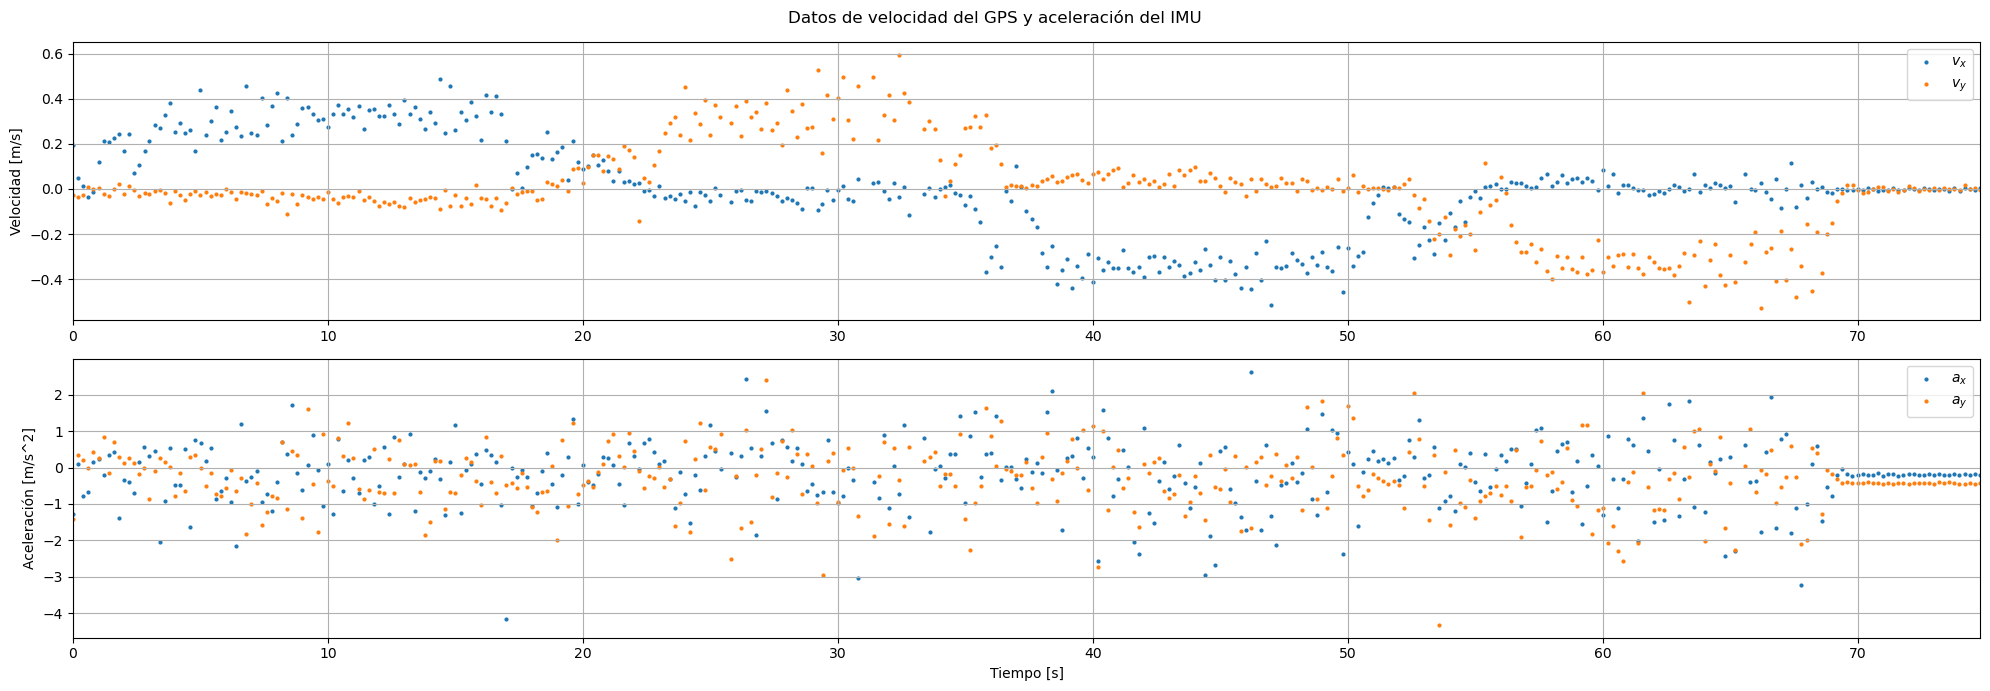

In [6]:
# Graficar velocidades del GPS y aceleraciones del IMU
plt.figure(figsize=(20, 7))

# Subplot para velocidades del GPS
ax1 = plt.subplot(211)
ax1.scatter(gps_t, gps_vx, s=4, label=r"$v_x$")
ax1.scatter(gps_t, gps_vy, s=4, label=r"$v_y$")
plt.xlim((gps_t[0], gps_t[-1]))
plt.ylabel("Velocidad [m/s]")
plt.legend()
plt.grid()

# Subplot para aceleraciones del IMU
plt.subplot(212, sharex=ax1)
plt.scatter(imu_t, imu_ax, s=4, label=r"$a_x$")
plt.scatter(imu_t, imu_ay, s=4, label=r"$a_y$")
plt.ylabel("Aceleración [m/s^2]")
plt.xlabel("Tiempo [s]")
plt.suptitle('Datos de velocidad del GPS y aceleración del IMU')
plt.tight_layout()
plt.legend()
plt.grid()
plt.show()

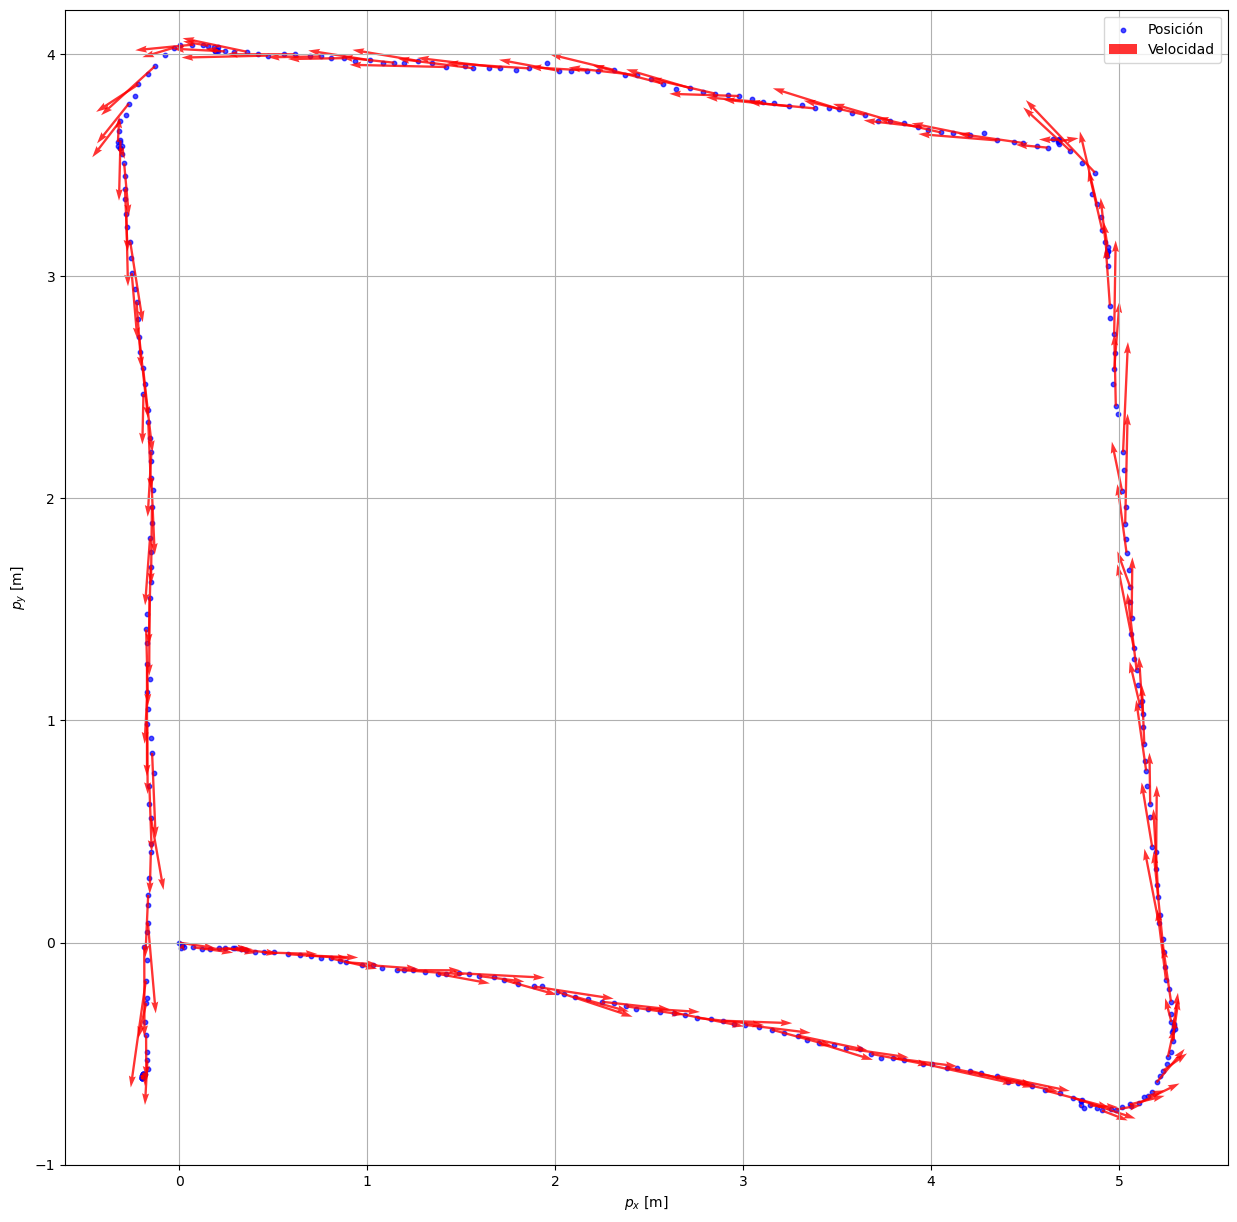

In [7]:
# Graficar trayectoria del GPS con vectores de velocidad
plt.figure(figsize=(15, 15))

plt.scatter(gps_x, gps_y, label='Posición', color='b', alpha=0.7, s=10)
plt.quiver(gps_x[::2], gps_y[::2], gps_vx[::2], gps_vy[::2],
           angles='xy', scale_units='xy', scale=1, width=0.002, color='red', label='Velocidad', alpha=0.8)

plt.xlabel('$p_x$ [m]')
plt.ylabel('$p_y$ [m]')
plt.ylim([-1, 4.2])
plt.grid(True)
plt.legend()
plt.savefig('gps_trajectory.pdf', bbox_inches='tight')
plt.show()

In [8]:
# Calcular el intervalo promedio de muestreo para GPS y IMU
delta_t = [gps_t[i+1] - gps_t[i] for i in range(len(gps_t) - 1)]
dt = np.mean(delta_t)  # Intervalo promedio de muestreo
# 0.05 s para IMU
# 0.2 s para GPS

## Configuración de parámetros y dimensiones del sistema

In [9]:
# Configuración de parámetros del sistema
USE_IMU = True            # Usar IMU o ruido aleatorio
ADD_OUTLIERS = True       # Agregar outliers a los datos del GPS
MEDIR_VELOCIDAD = False   # Medir velocidad o no

# Dimensiones del sistema
Ny = 4 if MEDIR_VELOCIDAD else 2  # Cantidad de mediciones
Nx = 4  # Cantidad de estados
Nu = 2 if USE_IMU else 0  # Cantidad de entradas
Nv = Ny  # Cantidad de ruido de medición
Nw = 4  # Cantidad de ruido del proceso
Nsim = np.size(gps_t)  # Número de pasos de tiempo
N = 10  # Tamaño de la ventana para MHE
N_dict = {'x': Nx, 'u': Nu, 'y': Ny, 'w': Nw, 't': N}  # Diccionario de dimensiones

# Matrices de covarianza
Q = 10.0 * cs.DM.eye(Nw)  # Matriz de covarianza del ruido del proceso
R = 0.1 * cs.DM.eye(Ny)   # Matriz de covarianza del ruido de medición

# Matrices del modelo
A = np.zeros((Nx, Nx))
B = np.zeros((Nx, Nu))
C = np.zeros((Ny, Nx))
D = np.eye(Nw)
A[0, 0] = A[1, 1] = A[2, 2] = A[3, 3] = 1
A[0, 2] = A[1, 3] = dt

if USE_IMU:
    B[0, 0] = B[1, 1] = dt**2 / 2
    B[2, 0] = B[3, 1] = dt

C[0, 0] = C[1, 1] = 1
if MEDIR_VELOCIDAD:
    C[2, 2] = C[3, 3] = 1

# Parámetros y variables del problema
x = cs.SX.sym('x', Nx)
u = cs.SX.sym('u', Nu)
w = cs.SX.sym('w', Nw)

# Función de estados y de medición
f_rhs = [cs.mtimes(A, x) + cs.mtimes(B, u) + w]
f_rhs = cs.vertcat(*f_rhs)

h_rhs = [cs.mtimes(C, x)]
h_rhs = cs.vertcat(*h_rhs)

f = cs.Function('f_discrete', [x, u, w], [f_rhs], ['x', 'u', 'w'], ['f_rhs'])
h = cs.Function('h', [x], [h_rhs], ['x'], ['h_rhs'])

### Mediciones y entradas del sistema

In [10]:
# Configuración de mediciones y entradas
if MEDIR_VELOCIDAD: # Mediciones del GPS con velocidad
    y_meas = np.vstack((gps_x, gps_y, gps_vx, gps_vy))
else: # Mediciones del GPS sin velocidad  
    y_meas = np.vstack((gps_x, gps_y))
x_meas = np.vstack((gps_x, gps_y, gps_vx, gps_vy))  # Estados del sistema

if USE_IMU:
    u_sim = np.vstack((imu_ax, imu_ay))  # Entradas del sistema
else:
    u_sim = np.zeros((Nu, Nsim))

# Generar ruido
v_sim = np.zeros((Nv, Nsim))

# Agregar outliers al ruido
if ADD_OUTLIERS:
    sigma_p = 1.5  # Desviación estándar de los outliers en la posición
    p = 0.10  # Probabilidad de outliers
    np.random.seed(35)
    inds = np.random.rand(Nsim) <= p  # Índices de los outliers
    v_sim[0:2, inds] = sigma_p * np.random.randn(2, Nsim)[:, inds]  # Outliers en posición
    if MEDIR_VELOCIDAD:
        sigma_v = 0.05  # Desviación estándar de los outliers en la velocidad
        v_sim[2:4, inds] = sigma_v * np.random.randn(2, Nsim)[:, inds]  # Outliers en velocidad
y_noisy = y_meas + v_sim

# Errores de posición y velocidad (según datasheet del GPS)
# Error de posición: 1.5 m
# Error de velocidad: 0.05 m/s

### Parámetros a usar

In [11]:
# Calcular jacobianos y definir parámetros iniciales
F, H, W = jacobiano(f, 0), jacobiano(h, 0), jacobiano(f, 2)
P_0 = cs.DM.eye(Nx)  # Matriz de peso de costo de arribo propuesta
x_0 = np.array([0, 0, 0, 0]).T  # Estado inicial propuesto

In [12]:
# Buscar el mejor parámetro rho para Huber
rhos = [0.01, 0.05, 0.1, 0.25, 0.5, 1, 1.345, 2]
best_rho = None
menor_error = float('inf')

for rho in rhos:
    x_huber, _, _, t_huber, _ = mhe(N_dict, f, h, x_0, u_sim, y_noisy, P_0, Q, R,
                                    f_jacx=F, f_jacw=W, h_jacx=H, rho_huber = rho) 
    mse_mheh = np.mean(np.square(x_huber - x_meas).mean(axis=1))
    if mse_mheh < menor_error:
        menor_error = mse_mheh
        best_rho = rho
    print(f'rho = {rho:0.3f}, MSE = {mse_mheh}')

print(f'-- Mejor rho = {best_rho:0.3f} --')

rho = 0.010, MSE = 0.1007331598578522
rho = 0.050, MSE = 0.12045347878968671
rho = 0.100, MSE = 0.15726699278816836
rho = 0.250, MSE = 0.1914578659098093
rho = 0.500, MSE = 0.19633567152271425
rho = 1.000, MSE = 0.1969406515039578
rho = 1.345, MSE = 0.1969406515039578
rho = 2.000, MSE = 0.1969406515039578
-- Mejor rho = 0.010 --


## Estimación

In [13]:
def calcular_mpe_MPE_mve_MVE(x_est, x_true):
    # Calcular el error de posición y velocidad
    error_pos = np.sqrt((x_est[0, :] - x_true[0, :])**2 + (x_est[1, :] - x_true[1, :])**2)
    error_vel = np.sqrt((x_est[2, :] - x_true[2, :])**2 + (x_est[3, :] - x_true[3, :])**2)
    
    # Calcular el mpe y mve
    mpe = np.mean(error_pos)
    mve = np.mean(error_vel)

    # Calcular el MPE y MVE
    MPE = np.max(error_pos)
    MVE = np.max(error_vel)
    
    return mpe, MPE, mve, MVE

In [14]:
test_parameters = False
if test_parameters:     
    D_mhe, D_huber = {}, {} # diccionarios para almacenar resultados de MHE y Huber
    ## Pruebo varios tamaños de ventana, de matriz P, y parámetros c y sigma para AD-VF
    for n in [5, 10]:
        for c in [1, 10, 100]:
            for sigma in [1e2, 1e3, 1e4, 1e5, 1e6]:
                for P_value in [1, 1e2, 1e3 , 1e6]:
                    N_dict['t'] = n
                    x_mhe_n, _, _, t_mhe_n, _ = mhe(N_dict, f, h, x_0, u_sim, y_noisy, P_value*cs.DM.eye(Nx), Q, R,
                                                    f_jacx=F, f_jacw=W, h_jacx=H,
                                                    update_P='AD-VF', c=c, sigma=sigma
                                                    )
                    D_mhe[(n, c, sigma, P_value)] = calcular_mpe_MPE_mve_MVE(x_mhe_n, x_meas)
                    x_huber_n, _, _, t_huber_n, _ = mhe(N_dict, f, h, x_0, u_sim, y_noisy, P_value*cs.DM.eye(Nx), Q, R,
                                                        f_jacx=F, f_jacw=W, h_jacx=H, rho_huber = best_rho, 
                                                        update_P='AD-VF', c=c, sigma=sigma
                                                        )
                    D_huber[(n, c, sigma, P_value)] = calcular_mpe_MPE_mve_MVE(x_huber_n, x_meas)

In [15]:
if test_parameters:
    # Mejores 10 combinaciones para MHE (ordenadas primero por mpe, luego por mve, luego por MPE, luego por MVE)
    mejores_mhe = sorted(D_mhe.items(), key=lambda x: (x[1][0], x[1][2], x[1][1], x[1][3]))[:10]
    print("\nMejores 10 combinaciones para MHE:")
    for params, metrics in mejores_mhe:
        print(f'N={params[0]}, c={params[1]}, sigma={params[2]}, P_0={params[3]}: mpe={metrics[0]:.3f}, MPE={metrics[1]:.3f}, mve={metrics[2]:.3f}, MVE={metrics[3]:.3f}')

    mejores_huber = sorted(D_huber.items(), key=lambda x: (x[1][0], x[1][2], x[1][1], x[1][3]))[:10]
    print("\nMejores 10 combinaciones para Huber:")
    for params, metrics in mejores_huber:
        print(f'N={params[0]}, c={params[1]}, sigma={params[2]}, P_0={params[3]}: mpe={metrics[0]:.3f}, MPE={metrics[1]:.3f}, mve={metrics[2]:.3f}, MVE={metrics[3]:.3f}')

# Mejores 10 combinaciones para MHE:
# N=10, c=1, sigma=1000000.0, P_0=1: mpe=0.127, MPE=4.091, mve=0.572, MVE=3.441
# N=10, c=10, sigma=1000000.0, P_0=1: mpe=0.127, MPE=4.091, mve=0.572, MVE=3.441
# N=10, c=100, sigma=1000000.0, P_0=1: mpe=0.127, MPE=4.091, mve=0.572, MVE=3.441
# N=10, c=1, sigma=100000.0, P_0=1: mpe=0.127, MPE=4.091, mve=0.572, MVE=3.441
# N=10, c=10, sigma=100000.0, P_0=1: mpe=0.127, MPE=4.091, mve=0.572, MVE=3.441
# N=10, c=100, sigma=100000.0, P_0=1: mpe=0.127, MPE=4.091, mve=0.572, MVE=3.441
# N=10, c=1, sigma=10000.0, P_0=1: mpe=0.127, MPE=4.091, mve=0.572, MVE=3.441
# N=10, c=10, sigma=10000.0, P_0=1: mpe=0.127, MPE=4.091, mve=0.572, MVE=3.441
# N=10, c=100, sigma=10000.0, P_0=1: mpe=0.127, MPE=4.091, mve=0.572, MVE=3.441
# N=10, c=1, sigma=1000.0, P_0=1: mpe=0.127, MPE=4.091, mve=0.572, MVE=3.441

# Mejores 10 combinaciones para Huber:
# N=10, c=1, sigma=1000000.0, P_0=1: mpe=0.034, MPE=0.697, mve=0.504, MVE=1.678
# N=10, c=10, sigma=1000000.0, P_0=1: mpe=0.034, MPE=0.697, mve=0.504, MVE=1.678
# N=10, c=100, sigma=1000000.0, P_0=1: mpe=0.034, MPE=0.697, mve=0.504, MVE=1.678
# N=10, c=1, sigma=100000.0, P_0=1: mpe=0.034, MPE=0.697, mve=0.504, MVE=1.678
# N=10, c=10, sigma=100000.0, P_0=1: mpe=0.034, MPE=0.697, mve=0.504, MVE=1.678
# N=10, c=100, sigma=100000.0, P_0=1: mpe=0.034, MPE=0.697, mve=0.504, MVE=1.678
# N=10, c=1, sigma=10000.0, P_0=1: mpe=0.034, MPE=0.697, mve=0.504, MVE=1.678
# N=10, c=10, sigma=10000.0, P_0=1: mpe=0.034, MPE=0.697, mve=0.504, MVE=1.678
# N=10, c=100, sigma=10000.0, P_0=1: mpe=0.034, MPE=0.697, mve=0.504, MVE=1.678
# N=10, c=1, sigma=1000.0, P_0=1: mpe=0.034, MPE=0.697, mve=0.504, MVE=1.679

In [16]:
# Resolver el problema de MHE y variantes
c = 10
sigma = 1e6
P_0 =  cs.DM.eye(Nx)  # Matriz de peso de costo de arribo propuesta
N_dict['t'] = 10
x_mhe, _, _, t_mhe, _ = mhe(N_dict, f, h, x_0, u_sim, y_noisy, P_0, Q, R,
                            f_jacx=F, f_jacw=W, h_jacx=H,
                            update_P='AD-VF', c=c, sigma=sigma
                            ) 

x_huber, _, _, t_huber, _ = mhe(N_dict, f, h, x_0, u_sim, y_noisy, P_0, Q, R,
                                f_jacx=F, f_jacw=W, h_jacx=H, rho_huber = best_rho, 
                                update_P='AD-VF', c=c, sigma=sigma
                                )

x_ekf, t_ekf, _ = resolver_ekf(N_dict, f, h, x_0, u_sim, y_noisy, P_0, Q, R, 
                            f_jacx=F, f_jacw=W, h_jacx=H)

In [17]:
N_dict['t'] = 5
x_mh5, _, _, t_mh5, _ = mhe(N_dict, f, h, x_0, u_sim, y_noisy, P_0, Q, R,
                            f_jacx=F, f_jacw=W, h_jacx=H,
                            update_P='AD-VF', c=c, sigma=sigma
                            ) 

x_hube5, _, _, t_hube5, _ = mhe(N_dict, f, h, x_0, u_sim, y_noisy, P_0, Q, R,
                                f_jacx=F, f_jacw=W, h_jacx=H, rho_huber = best_rho, 
                                update_P='AD-VF', c=c, sigma=sigma
                                )

### Tablas de resultados

In [ ]:
imu = {False: 'sin IMU', True: 'con IMU'}[USE_IMU]
vel = {False: 'sin medición de velocidad', True: 'con medición de velocidad'}[MEDIR_VELOCIDAD]
# Calcular errores de posición y velocidad
mpe_ekf, MPE_ekf, mve_ekf, MVE_ekf = calcular_mpe_MPE_mve_MVE(x_ekf, x_meas)
mpe_mhe, MPE_mhe, mve_mhe, MVE_mhe = calcular_mpe_MPE_mve_MVE(x_mhe, x_meas)
mpe_huber, MPE_huber, mve_huber, MVE_huber = calcular_mpe_MPE_mve_MVE(x_huber, x_meas)
mpe_mh5, MPE_mh5, mve_mh5, MVE_mh5 = calcular_mpe_MPE_mve_MVE(x_mh5, x_meas)
mpe_hube5, MPE_hube5, mve_hube5, MVE_hube5 = calcular_mpe_MPE_mve_MVE(x_hube5, x_meas)
T_ekf = np.mean(t_ekf) * 1000
T_mhe = np.mean(t_mhe) * 1000
T_huber = np.mean(t_huber) * 1000
T_mh5 = np.mean(t_mh5) * 1000
T_hube5 = np.mean(t_hube5) * 1000

print(f'Errores ({imu}, {vel}):')
print('-')
print( "|       |    |  Position   |  Velocity   |  MCT |")
print( "|       |    |  Error [m]  | Error [m/s] | [ms] |")
print( '|       |    | mean | max  | mean | max  |      |')
print( '|-------|----|------|------|------|------|------|')
print(f'|  EKF  | -  |{mpe_ekf:6.3f}|{MPE_ekf:6.3f}|{mve_ekf:6.3f}|{MVE_ekf:6.3f}|{T_ekf:6.3f}|')
print(f'|  MHE  |  5 |{mpe_mh5:6.3f}|{MPE_mh5:6.3f}|{mve_mh5:6.3f}|{MVE_mh5:6.3f}|{T_mh5:6.3f}|')
print(f'| MHE-H |  5 |{mpe_hube5:6.3f}|{MPE_hube5:6.3f}|{mve_hube5:6.3f}|{MVE_hube5:6.3f}|{T_hube5:6.3f}|')
print(f'|  MHE  | 10 |{mpe_mhe:6.3f}|{MPE_mhe:6.3f}|{mve_mhe:6.3f}|{MVE_mhe:6.3f}|{T_mhe:6.3f}|')
print(f'| MHE-H | 10 |{mpe_huber:6.3f}|{MPE_huber:6.3f}|{mve_huber:6.3f}|{MVE_huber:6.3f}|{T_huber:6.3f}|')
print('_')

Errores (con IMU, sin medición de velocidad):
-
|       |    |  Position   |  Velocity   |  MCT |
|       |    |  Error [m]  | Error [m/s] | [ms] |
|       |    | mean | max  | mean | max  |      |
|-------|----|------|------|------|------|------|
|  EKF  | -  | 0.175| 4.169| 0.604| 3.285| 0.349|
|  MHE  |  5 | 0.127| 4.090| 0.559| 3.274| 2.327|
| MHE-H |  5 | 0.035| 0.561| 0.527| 1.573| 2.737|
|  MHE  | 10 | 0.127| 4.091| 0.572| 3.441| 2.810|
| MHE-H | 10 | 0.034| 0.697| 0.504| 1.678| 3.657|
_


### Gráficas de resultados

In [19]:
# Configuración de parámetros para graficar
# labels para cada método:
lab = ['Measurements', 'Reference', 'EKF', 'MHE', 'MHE-H']
# Seteo paleta de colores
color_palette = sns.color_palette("muted")
colors = {lab[0]: sns.color_palette("colorblind")[8],
          lab[1]: 'k',
          lab[2]: color_palette[0],
          lab[3]: color_palette[1],
          lab[4]: color_palette[2]
          }
# Tamaño de labels
label_size = 12
# Tamaño de los puntos de las mediciones
marker_size = 2.5
# Tamaño de gráficos
figsize = (7, 5)
# Seteo grosor de líneas
lw = 1.5

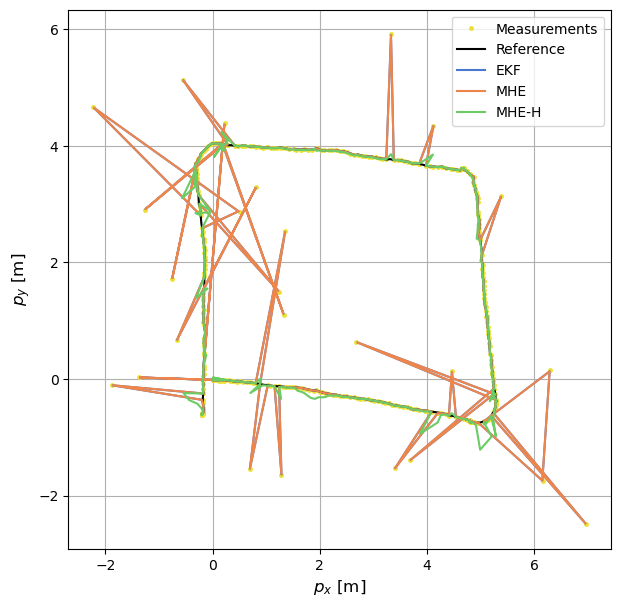

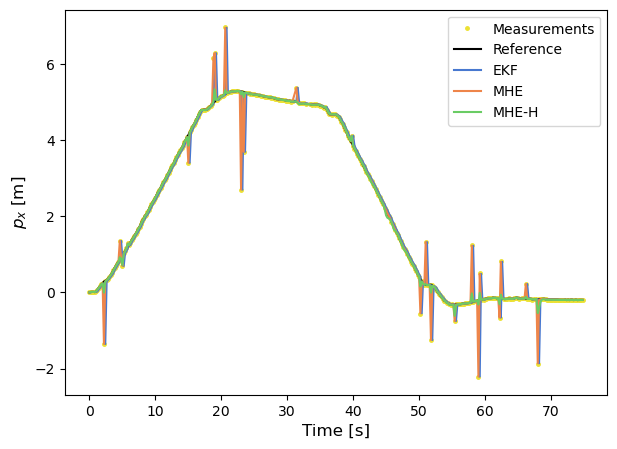

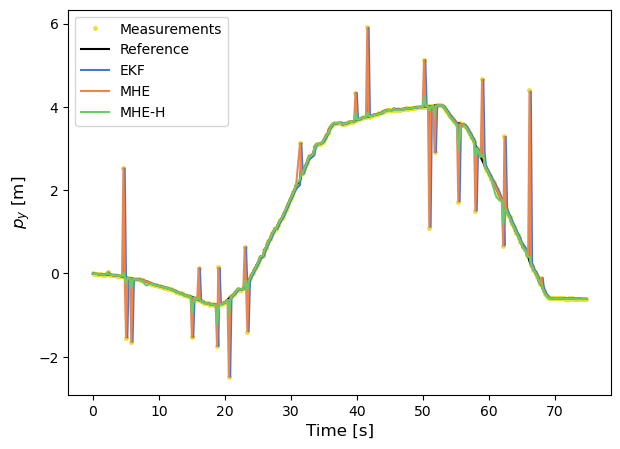

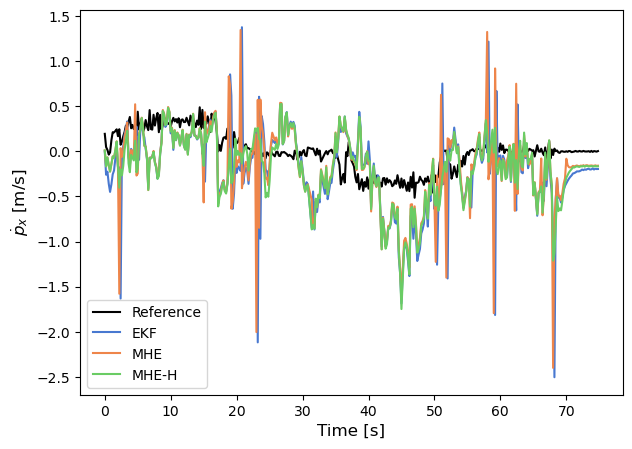

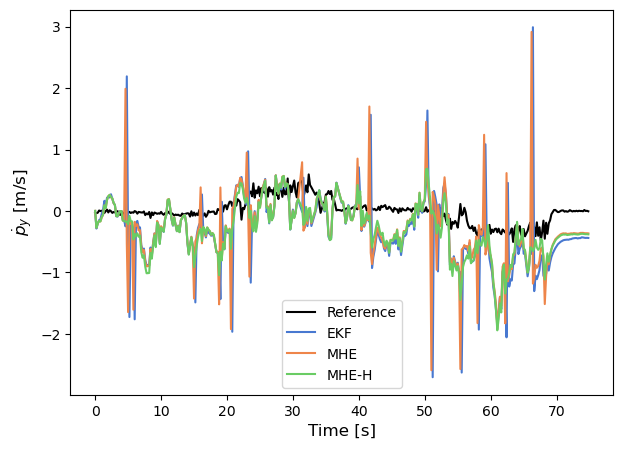

In [ ]:
# Graficar estimaciones y referencias
ploteo = True

if ploteo:
    plt.figure(figsize=(7, 7))
    plt.plot(y_noisy[0, :], y_noisy[1, :], 'o', label=lab[0], color=colors[lab[0]], markersize=marker_size)
    plt.plot(gps_x, gps_y, label=lab[1], color=colors[lab[1]], linewidth=lw)
    plt.plot(np.array(x_ekf)[0, :], np.array(x_ekf)[1, :], label=lab[2], color=colors[lab[2]], linewidth=lw)
    plt.plot(np.array(x_mh5)[0, :], np.array(x_mh5)[1, :], label=lab[3], color=colors[lab[3]], linewidth=lw)
    plt.plot(np.array(x_hube5)[0, :], np.array(x_hube5)[1, :], label=lab[4], color=colors[lab[4]], linewidth=lw)
    plt.xlabel('$p_x$ [m]', size=label_size)
    plt.ylabel('$p_y$ [m]', size=label_size)
    plt.grid('on')
    plt.legend(loc='best')
    plt.savefig('gps_trajectory_estimation.png', bbox_inches='tight')

    plt.figure(figsize=figsize)
    plt.plot(gps_t, y_noisy[0, :], 'o', label=lab[0], color=colors[lab[0]], markersize=marker_size)
    plt.plot(gps_t, gps_x, label=lab[1], color=colors[lab[1]], linewidth=lw)
    plt.plot(gps_t, np.array(x_ekf)[0, :], label=lab[2], color=colors[lab[2]], linewidth=lw)
    plt.plot(gps_t, np.array(x_mhe)[0, :], label=lab[3], color=colors[lab[3]], linewidth=lw)
    plt.plot(gps_t, np.array(x_huber)[0, :], label=lab[4], color=colors[lab[4]], linewidth=lw)
    plt.xlabel('Time [s]', size=label_size)
    plt.ylabel('$p_x$ [m]', size=label_size)
    plt.legend()
    plt.savefig('gps_position_x.pdf', bbox_inches='tight')

    plt.figure(figsize=figsize)
    plt.plot(gps_t, y_noisy[1, :], 'o', label=lab[0], color=colors[lab[0]], markersize=marker_size)
    plt.plot(gps_t, gps_y, label=lab[1], color=colors[lab[1]], linewidth=lw)
    plt.plot(gps_t, np.array(x_ekf)[1, :], label=lab[2], color=colors[lab[2]], linewidth=lw)
    plt.plot(gps_t, np.array(x_mhe)[1, :], label=lab[3], color=colors[lab[3]], linewidth=lw)
    plt.plot(gps_t, np.array(x_huber)[1, :], label=lab[4], color=colors[lab[4]], linewidth=lw)
    plt.xlabel('Time [s]', size=label_size)
    plt.ylabel('$p_y$ [m]', size=label_size)
    plt.legend()
    plt.savefig('gps_position_y.pdf', bbox_inches='tight')

    plt.figure(figsize=figsize)
    plt.plot(gps_t, gps_vx, label=lab[1], color=colors[lab[1]], linewidth=lw)
    plt.plot(gps_t, np.array(x_ekf)[2, :], label=lab[2], color=colors[lab[2]], linewidth=lw)
    plt.plot(gps_t, np.array(x_mhe)[2, :], label=lab[3], color=colors[lab[3]], linewidth=lw)
    plt.plot(gps_t, np.array(x_huber)[2, :], label=lab[4], color=colors[lab[4]], linewidth=lw)
    plt.xlabel('Time [s]', size=label_size)
    plt.ylabel('$\dot{p}_x$ [m/s]', size=label_size)
    plt.legend()
    plt.savefig('gps_speed_x.pdf', bbox_inches='tight')

    plt.figure(figsize=figsize)
    plt.plot(gps_t, gps_vy, label=lab[1], color=colors[lab[1]], linewidth=lw)
    plt.plot(gps_t, np.array(x_ekf)[3, :], label=lab[2], color=colors[lab[2]], linewidth=lw)
    plt.plot(gps_t, np.array(x_mhe)[3, :], label=lab[3], color=colors[lab[3]], linewidth=lw)
    plt.plot(gps_t, np.array(x_huber)[3, :], label=lab[4], color=colors[lab[4]], linewidth=lw)
    plt.xlabel('Time [s]', size=label_size)
    plt.ylabel('$\dot{p}_y$ [m/s]', size=label_size)
    plt.legend()
    plt.savefig('gps_speed_y.pdf', bbox_inches='tight')
    
    plt.show()

In [21]:
pe_ekf = np.sqrt(np.square(np.array(x_ekf)[0,:]-x_meas[0,:]) + np.square(np.array(x_ekf)[1,:]-x_meas[1,:]))
pe_mhe = np.sqrt(np.square(np.array(x_mhe)[0,:]-x_meas[0,:]) + np.square(np.array(x_mhe)[1,:]-x_meas[1,:]))
pe_huber = np.sqrt(np.square(np.array(x_huber)[0,:]-x_meas[0,:]) + np.square(np.array(x_huber)[1,:]-x_meas[1,:]))
pe_mh5 = np.sqrt(np.square(np.array(x_mh5)[0,:]-x_meas[0,:]) + np.square(np.array(x_mh5)[1,:]-x_meas[1,:]))
pe_hube5 = np.sqrt(np.square(np.array(x_hube5)[0,:]-x_meas[0,:]) + np.square(np.array(x_hube5)[1,:]-x_meas[1,:]))

v_ekf = np.sqrt(np.square(np.array(x_ekf)[2,:]-x_meas[2,:]) + np.square(np.array(x_ekf)[3,:]-x_meas[3,:]))
v_mhe = np.sqrt(np.square(np.array(x_mhe)[2,:]-x_meas[2,:]) + np.square(np.array(x_mhe)[3,:]-x_meas[3,:]))
v_huber = np.sqrt(np.square(np.array(x_huber)[2,:]-x_meas[2,:]) + np.square(np.array(x_huber)[3,:]-x_meas[3,:]))
v_mh5 = np.sqrt(np.square(np.array(x_mh5)[2,:]-x_meas[2,:]) + np.square(np.array(x_mh5)[3,:]-x_meas[3,:]))
v_hube5 = np.sqrt(np.square(np.array(x_hube5)[2,:]-x_meas[2,:]) + np.square(np.array(x_hube5)[3,:]-x_meas[3,:]))

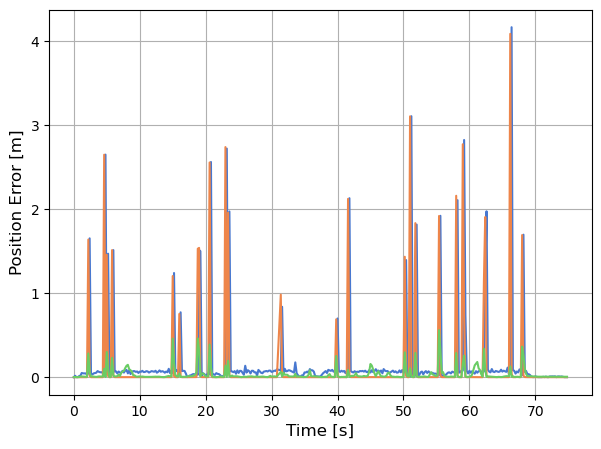

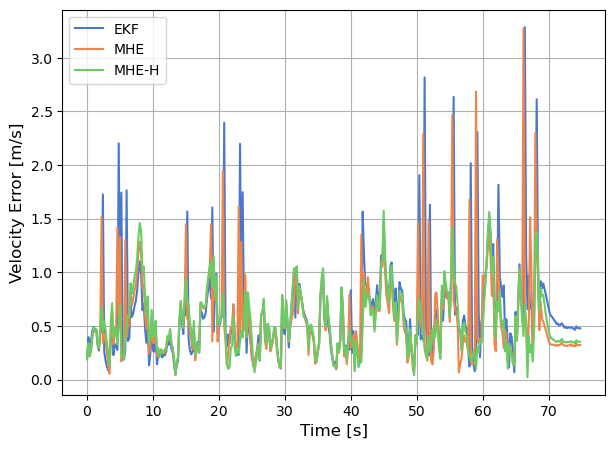

In [23]:
# Graficar errores de posición y velocidad
plt.figure(figsize=(7, 5))
plt.plot(gps_t, pe_ekf, label=lab[2], color=colors[lab[2]], linewidth=lw)
plt.plot(gps_t, pe_mh5, label=lab[3], color=colors[lab[3]], linewidth=lw)
plt.plot(gps_t, pe_hube5, label=lab[4], color=colors[lab[4]], linewidth=lw)
plt.xlabel('Time [s]', size=label_size)
plt.ylabel('Position Error [m]', size=label_size)
# plt.legend()
plt.grid('on')
plt.savefig('position_error.pdf', bbox_inches='tight')

plt.figure(figsize=(7, 5))
plt.plot(gps_t, v_ekf, label=lab[2], color=colors[lab[2]], linewidth=lw)
plt.plot(gps_t, v_mh5, label=lab[3], color=colors[lab[3]], linewidth=lw)
plt.plot(gps_t, v_hube5, label=lab[4], color=colors[lab[4]], linewidth=lw)
plt.xlabel('Time [s]', size=label_size)
plt.ylabel('Velocity Error [m/s]', size=label_size)
plt.legend()
plt.grid('on')
plt.savefig('velocity_error.pdf', bbox_inches='tight')
plt.show()